In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

from korean_font import set_korean_font

import warnings
warnings.filterwarnings("ignore")

set_korean_font()

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)


In [83]:
# 경로 설정
HOME = os.getcwd()

trainpath = os.path.join(HOME, 'data', 'train.csv')
testpath = os.path.join(HOME, 'data', 'test.csv')
interpath = os.path.join(HOME, 'data', 'international_trade.csv')

In [84]:
# 파일 읽기
train_df = pd.read_csv(trainpath)
test_df = pd.read_csv(testpath)
inter_df = pd.read_csv(interpath)

In [85]:
# 컬럼명 변경
train_df.rename(columns={'supply(kg)':'supply', 'price(원/kg)':'price'}, inplace = True)

In [86]:
# 데이터 타입 변경
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

# 연, 월,  일, 요일, 계절 컬럼 추가
train_df['year'] = train_df['timestamp'].dt.year
train_df['month'] = train_df['timestamp'].dt.month
train_df['day'] = train_df['timestamp'].dt.day
train_df['dow'] = train_df['timestamp'].dt.dayofweek

def get_season(month):
    if month in [12, 1, 2]:
        return int('1') # 겨울
    elif month in [3, 4, 5]:
        return int('2') # 봄
    elif month in [6, 7, 8]:
        return int('3') # 여름
    else:
        return int('4') # 가을
        
train_df['season'] = train_df['month'].apply(get_season)

In [87]:
# 한국 공휴일 불러오기
kr_holidays = holidays.KR()

#  공휴일 컬럼 추가
train_df['holiday'] = train_df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)

# 공휴일이면서 판매가 있었던 컬럼 구분
train_df['holi_sale'] = 0
train_df.loc[(train_df['holiday'] == 1) & ((train_df['price'] > 0) | (train_df['supply'] > 0)), 'holi_sale'] = 1

In [88]:
train_df

,ID,timestamp,item,corporation,location,supply,price,year,month,day,dow,season,holiday,holi_sale
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0,2019,1,1,1,1,1,0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0,2019,1,2,2,1,0,0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0,2019,1,3,3,1,0,0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0,2019,1,4,4,1,0,0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0,2019,1,5,5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59392,RD_F_J_20230227,2023-02-27,RD,F,J,452440.0,468.0,2023,2,27,0,1,0,0
59393,RD_F_J_20230228,2023-02-28,RD,F,J,421980.0,531.0,2023,2,28,1,1,0,0
59394,RD_F_J_20230301,2023-03-01,RD,F,J,382980.0,574.0,2023,3,1,2,2,1,1
59395,RD_F_J_20230302,2023-03-02,RD,F,J,477220.0,523.0,2023,3,2,3,2,0,0


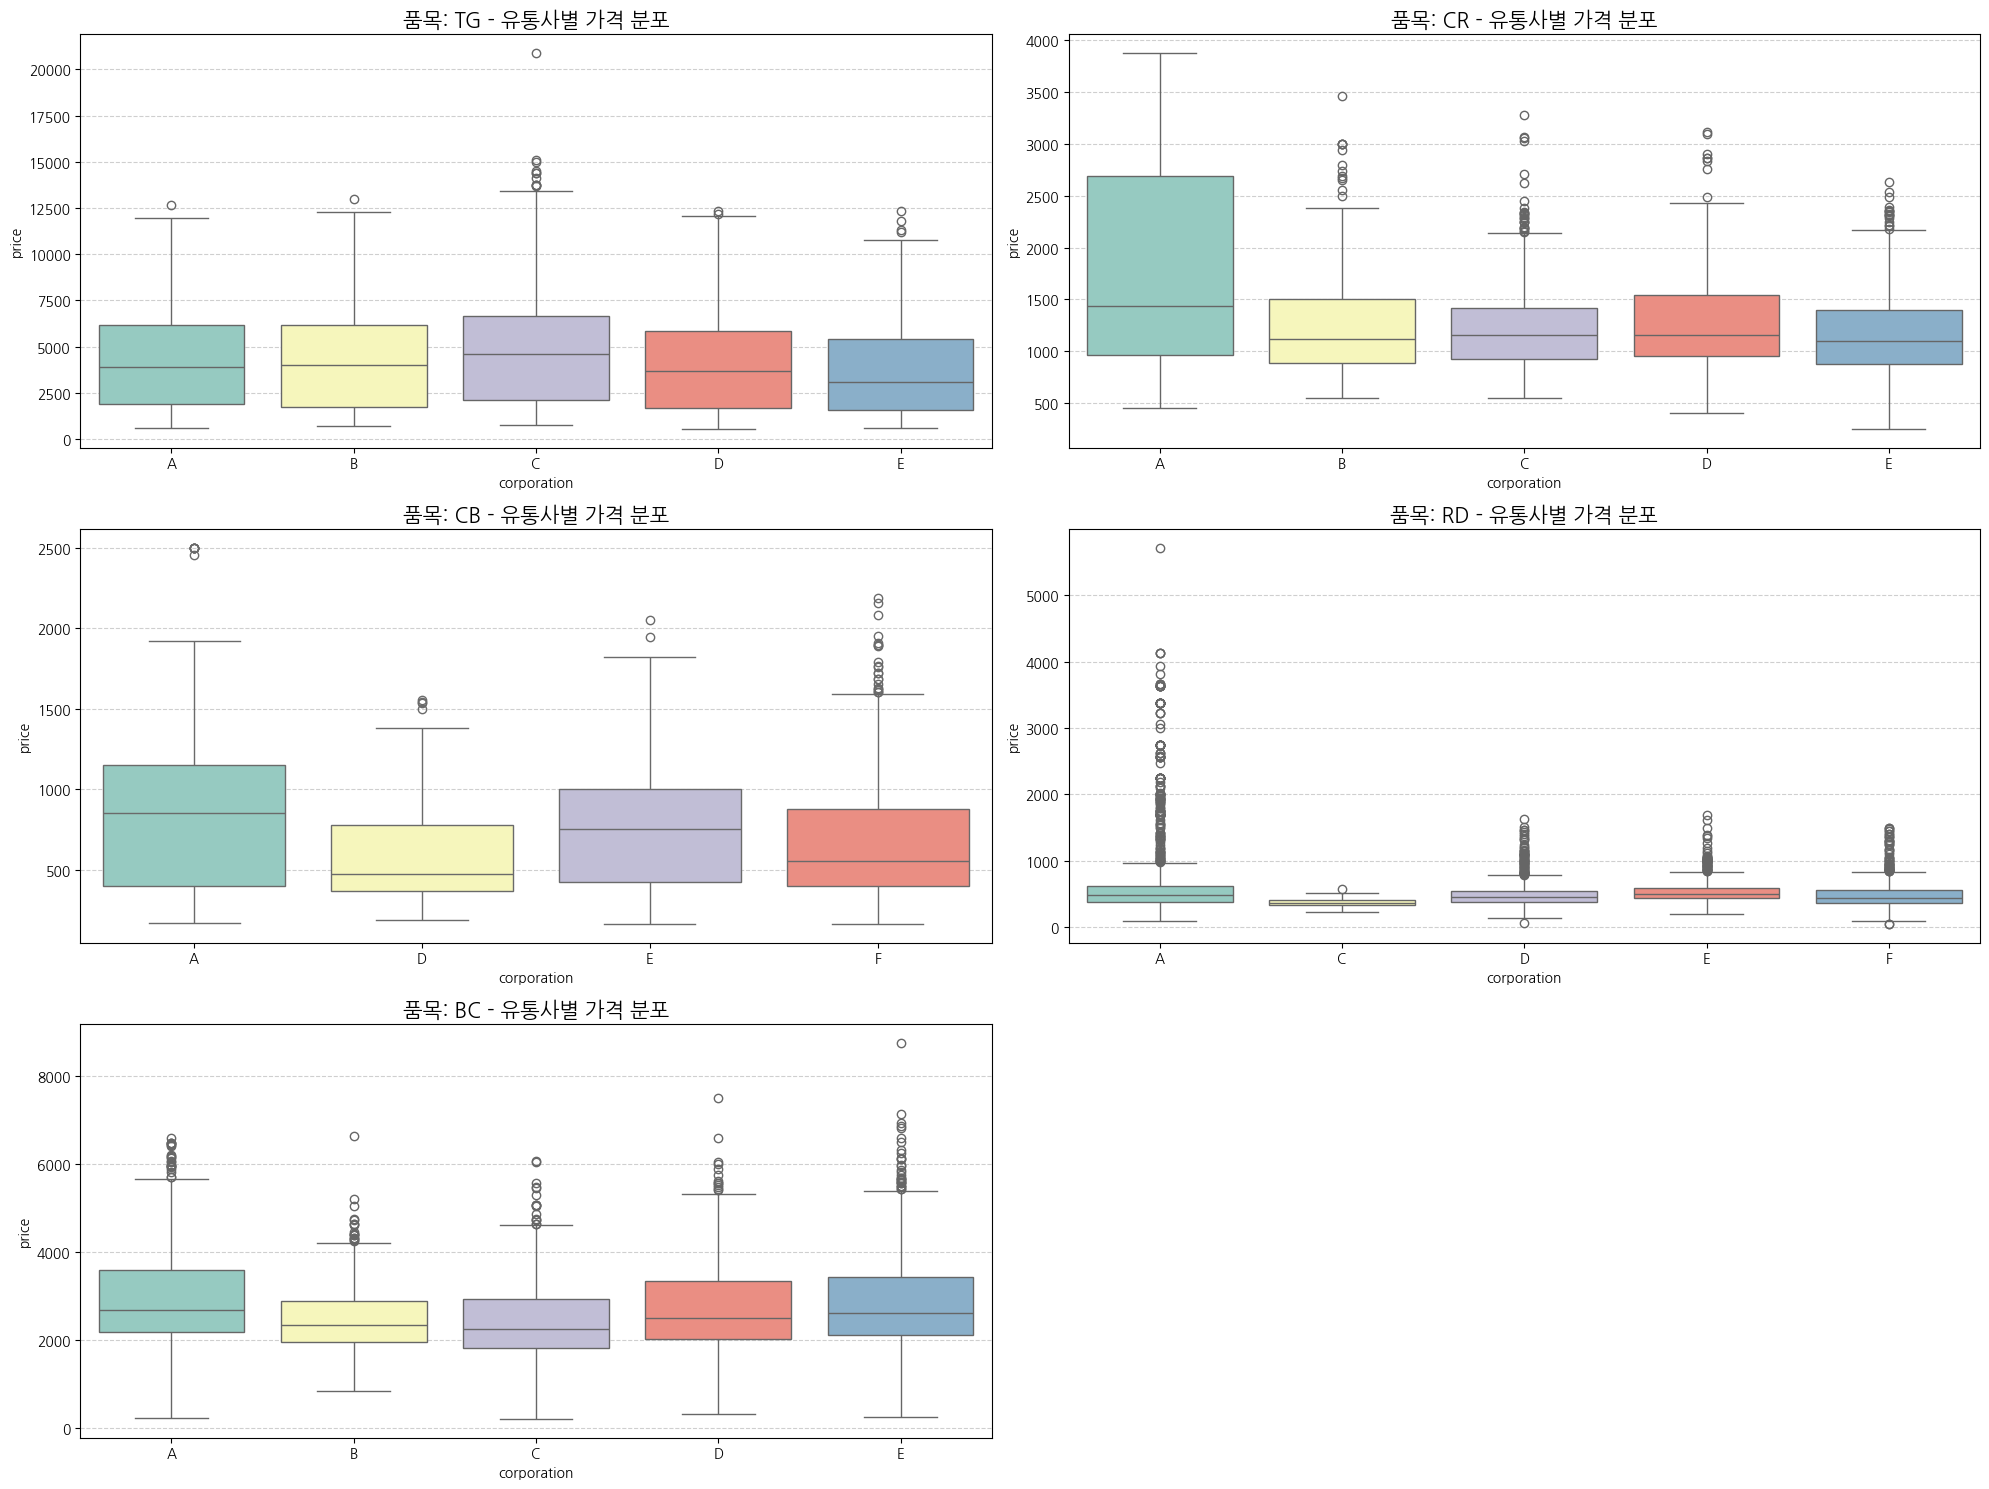

In [89]:
# 5개 품목 리스트
items = train_df['item'].unique()

# 유통사별 시각화
plt.figure(figsize=(20, 15))
for i, item in enumerate(items, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=train_df_active[train_df_active['item'] == item].sort_values('corporation'), 
                x='corporation', y='price', palette='Set3')
    plt.title(f'품목: {item} - 유통사별 가격 분포', fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

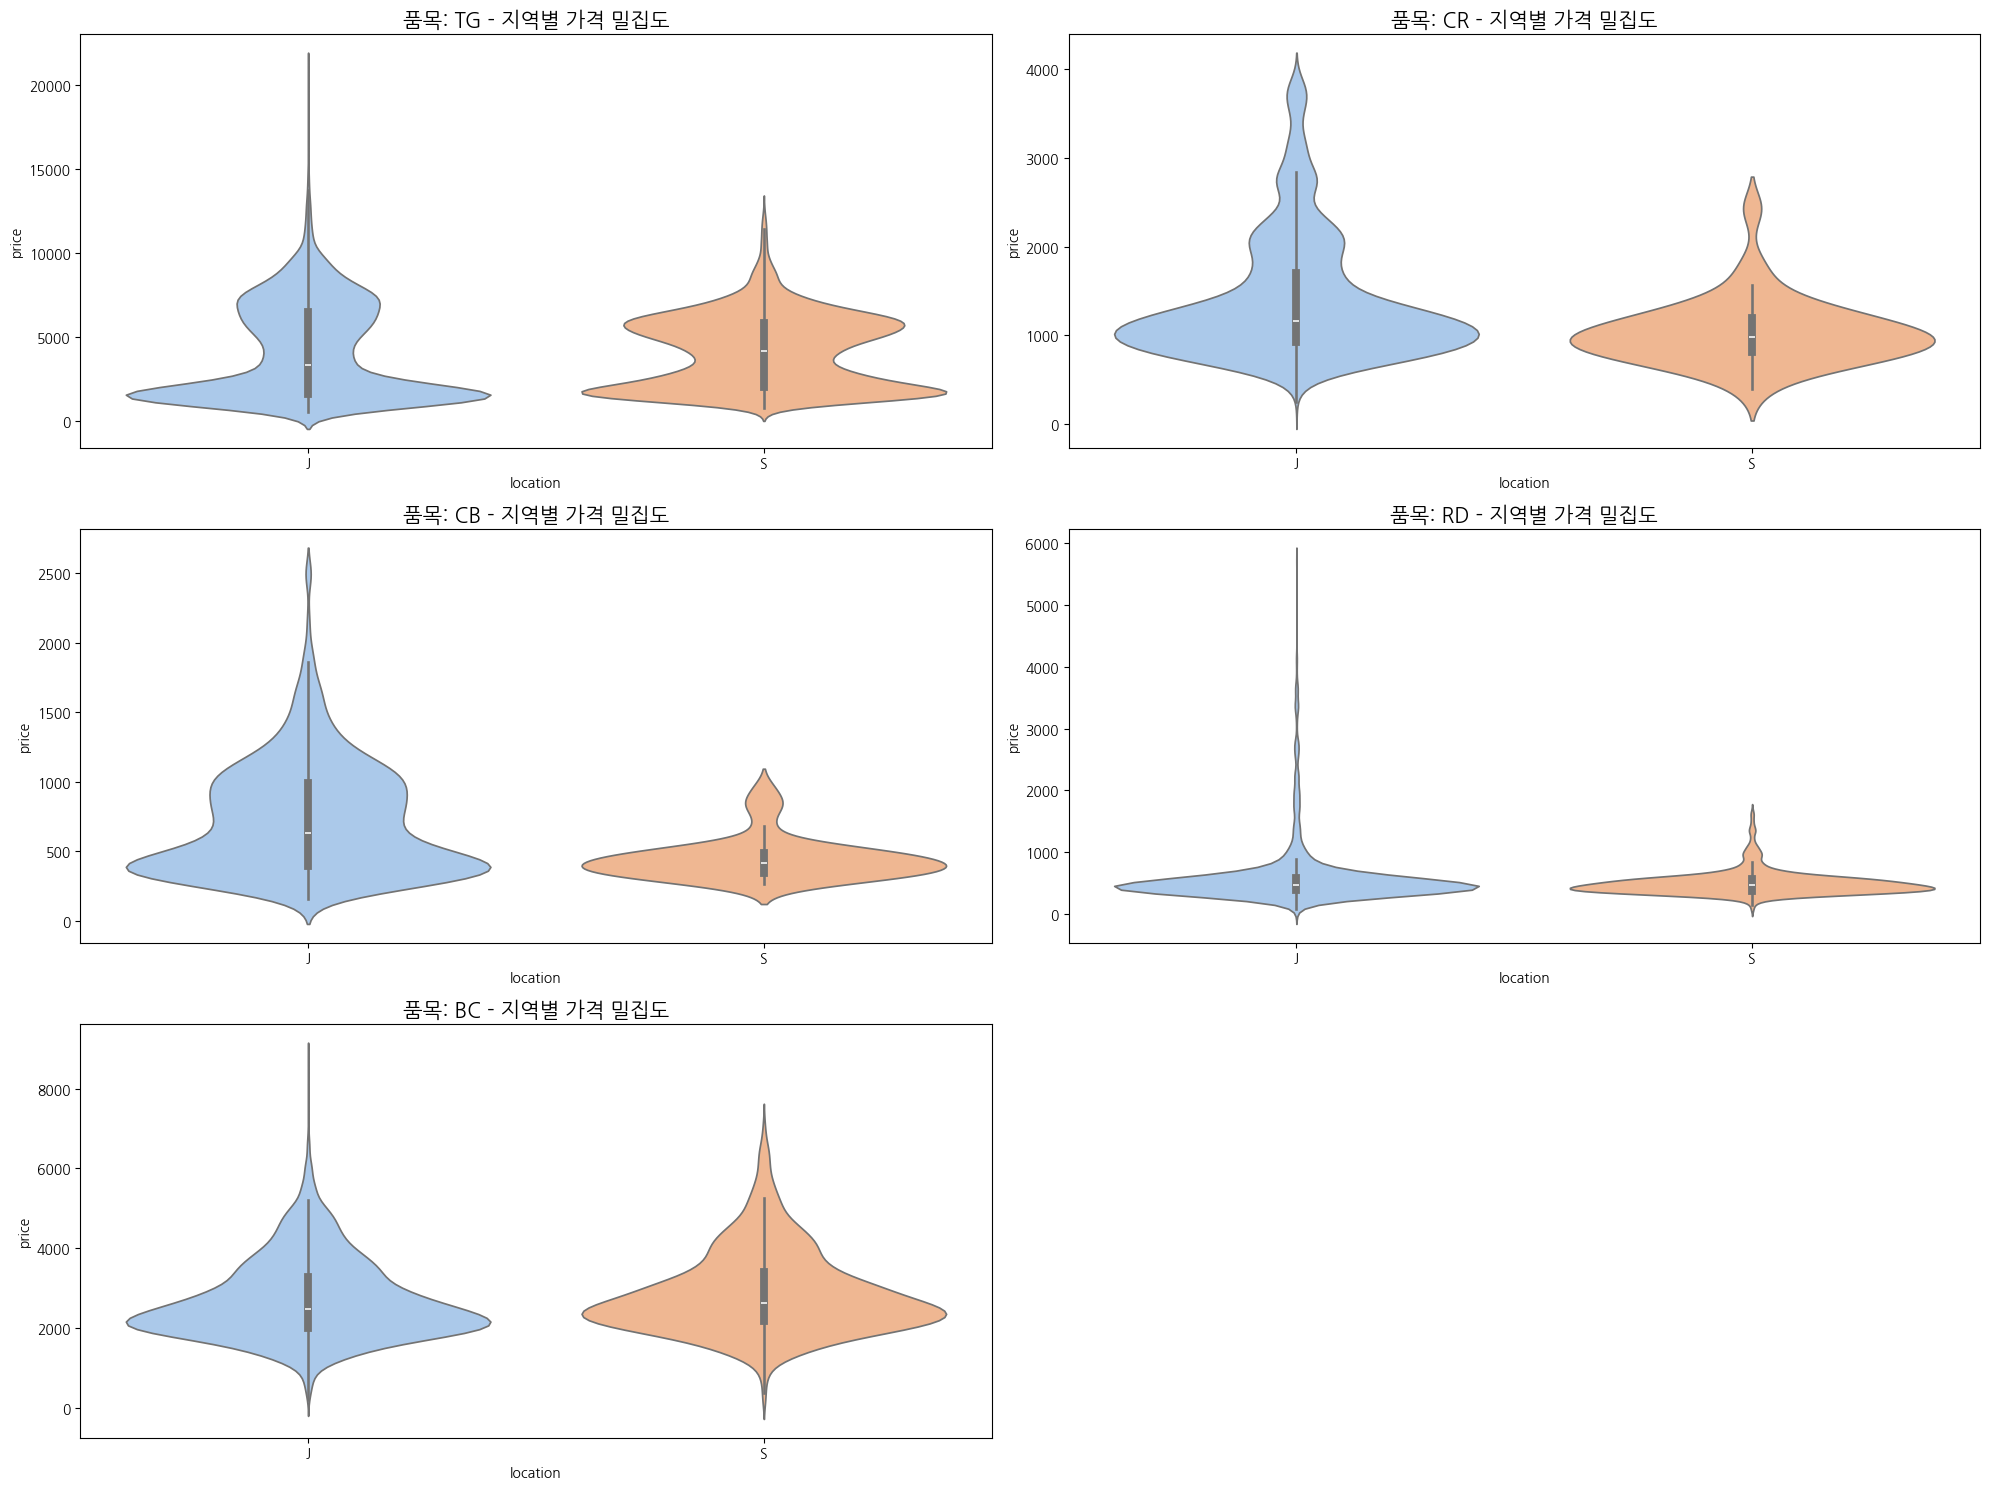

In [ ]:
# 지역별 시각화
plt.figure(figsize=(20, 15))
for i, item in enumerate(items, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(data=train_df_active[train_df_active['item'] == item], 
                   x='location', y='price', palette='pastel')
    plt.title(f'품목: {item} - 지역별 가격 밀집도', fontsize=15)

plt.tight_layout()
plt.show()

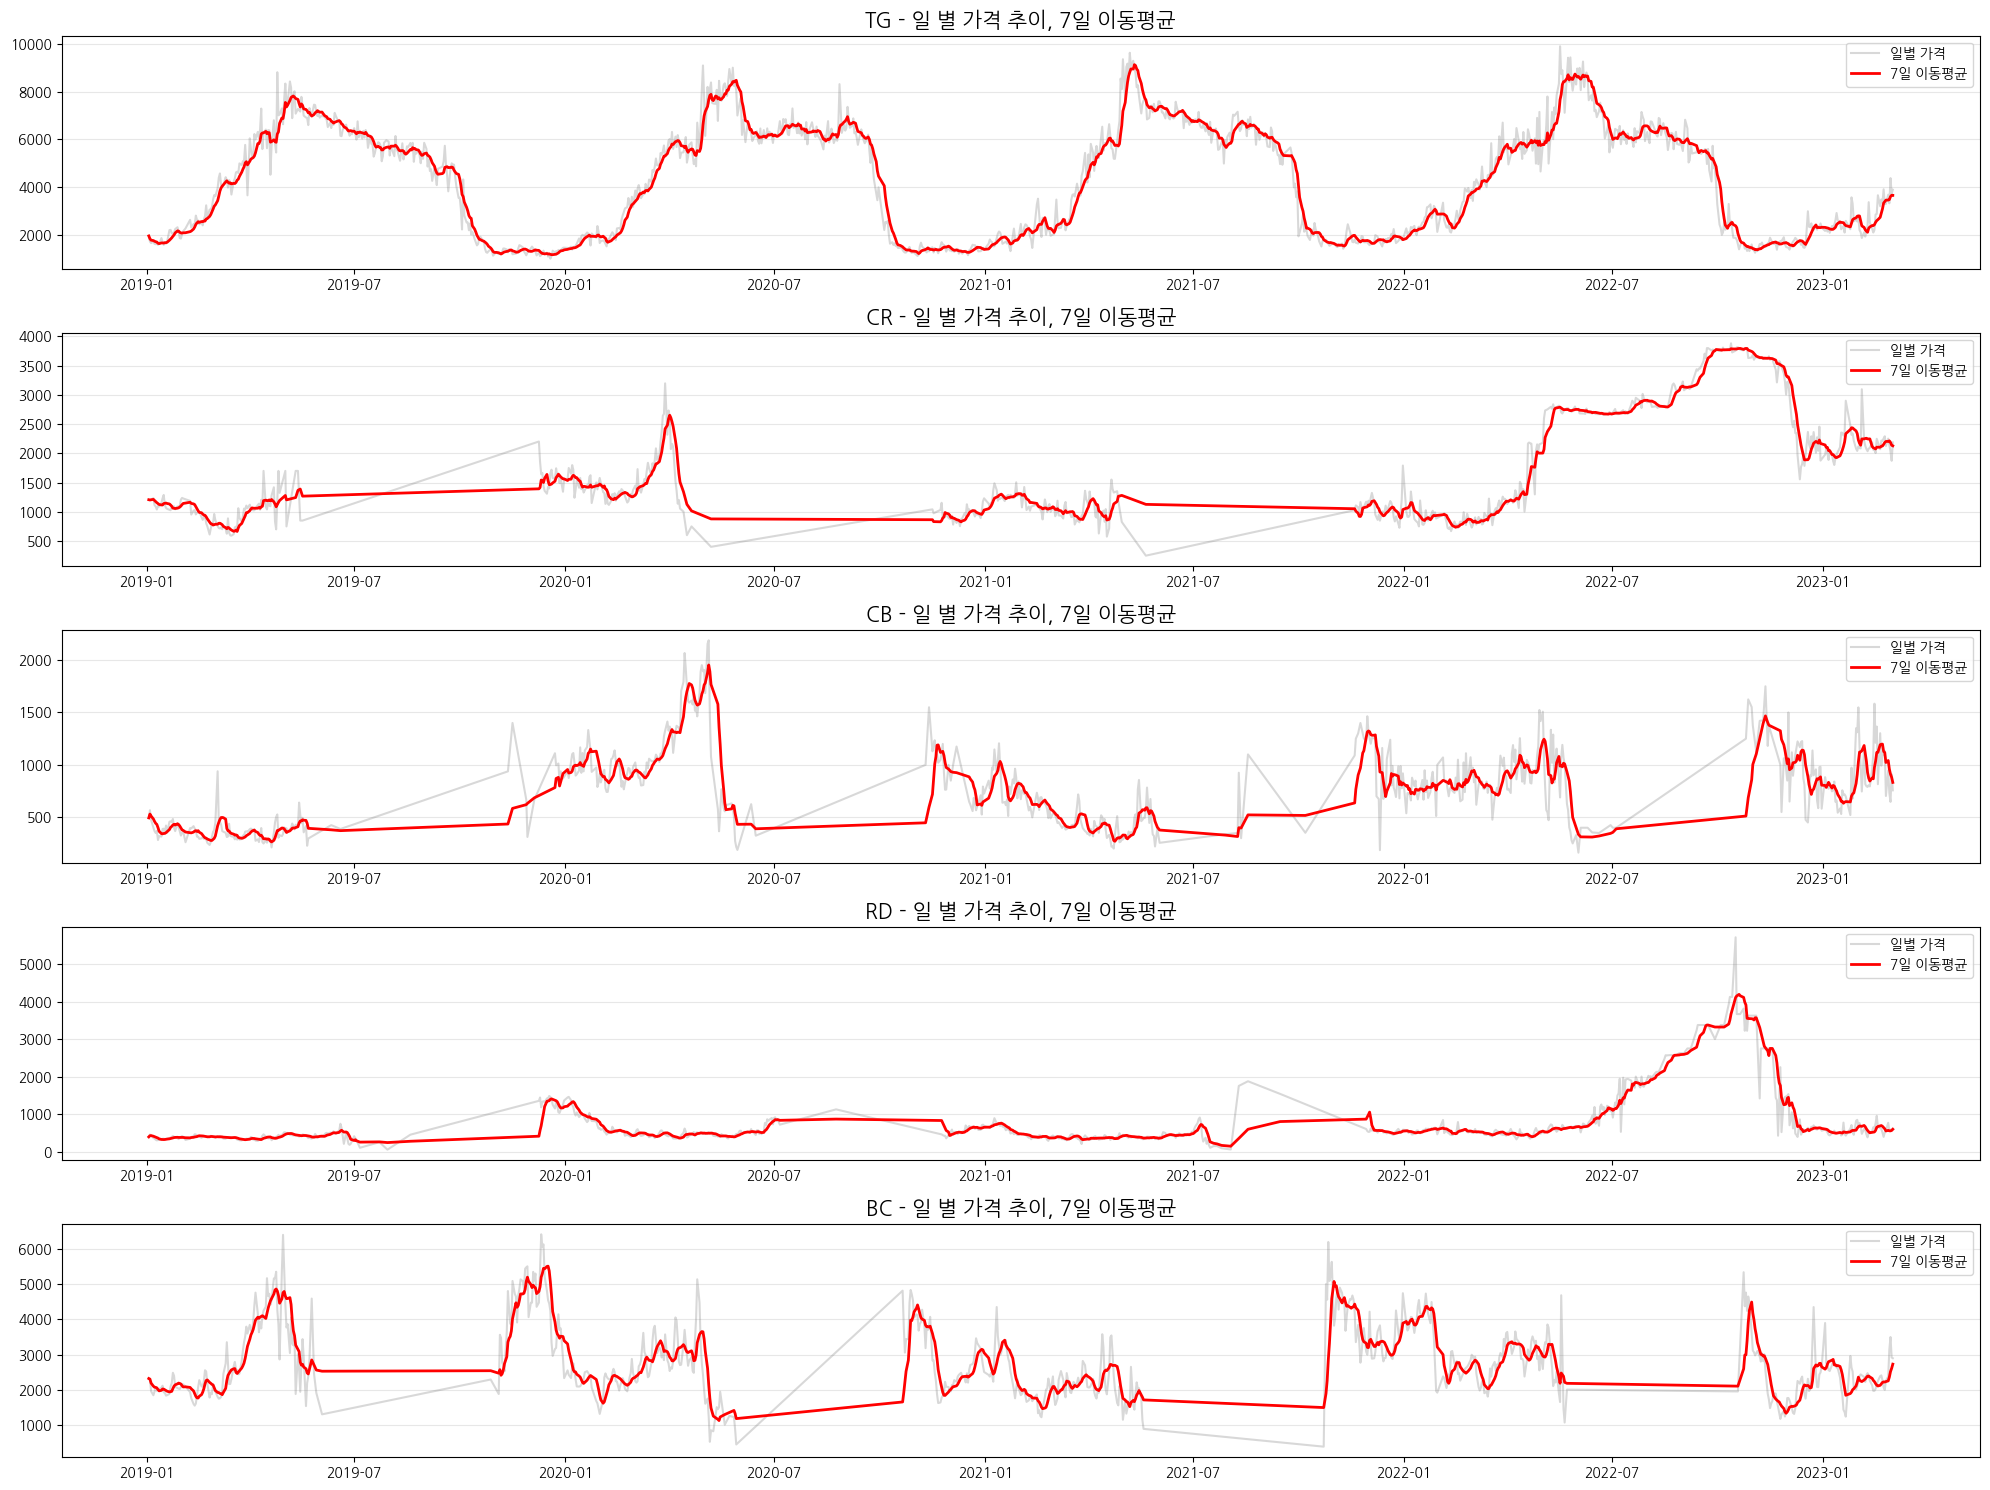

In [ ]:
# 가격이 0원인 데이터를 데이터 생성
df_plot = train_df[train_df['price'] > 0].copy()
items = df_plot['item'].unique()

plt.figure(figsize=(20, 15))

for i, item in enumerate(items, 1):
    plt.subplot(5, 1, i)
    target = df_plot[df_plot['item'] == item].groupby('timestamp')['price'].mean().reset_index()
    
    # 7일 이동평균 계산
    target['rolling_7'] = target['price'].rolling(window=7, min_periods=1).mean()
    
    # 시각화
    plt.plot(target['timestamp'], target['price'], alpha=0.3, label='일별 가격', color='gray')
    plt.plot(target['timestamp'], target['rolling_7'], label='7일 이동평균', color='red', linewidth=2)
    
    plt.title(f'{item} - 일별 가격 추이, 7일 이동평균', fontsize=15)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()